In [12]:
import plotly.graph_objs as go
from plotly import express as px
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Union
import onnxruntime
import numpy as np
import os
import cv2
import torch
from tqdm import tqdm
import pandas as pd
from torch.utils.data import Dataset
from timeit import default_timer as timer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
import warnings

warnings.filterwarnings("ignore")


from utils.config import Settings
from dataset_utils.dataloader import DataLoaderUtils
from dataset_utils.readers import ImageReader, LabelReader
from model_utils.model_architecture import get_model
from inference_utils.test import Test
from inference_utils.room_classifier_model import RoomTypeClassification

settings = Settings()
dataloader_utils = DataLoaderUtils()
onnx_model_path = f"{settings.LOGGED_MODELS_PATH}/best.onnx"
# onnx_model_path = "./Models/mobilenet_v3_large_corrected/best.onnx"

In [11]:
import os, shutil, random
# I would C:\Users\Kuba\Desktop\KubiK\STUDIA\Ekonomia UW\Praca Magisterska\NYC\Images_Analysis\Room_Classifier\dataset
path = r'C:\Users\Kuba\Desktop\KubiK\STUDIA\Ekonomia UW\Praca Magisterska\NYC\Images_Analysis\Room_Classifier\dataset'
destination = r'C:\Users\Kuba\Desktop\KubiK\STUDIA\Ekonomia UW\Praca Magisterska\Project\Image_Analysis\Room_Classifier\dataset'
names = ["train", "val", "test"]
for subset in names:
    subset_source_path = os.path.join(path, subset)
    subset_dest_path = os.path.join(destination, subset)
    if not os.path.exists(subset_dest_path):
        os.makedirs(subset_dest_path)
    for folder in sorted(os.listdir(subset_source_path)):
        folder_source_path = os.path.join(subset_source_path, folder)
        folder_dest_path = os.path.join(subset_dest_path, folder)
        if not os.path.exists(folder_dest_path):
            os.makedirs(folder_dest_path)
        #Choose 5 random png files and copy them
        folder_files = random.sample([os.path.join(folder_source_path, file_name) for file_name in os.listdir(folder_source_path)], 5)
        for file in folder_files:
            shutil.copy(file, folder_dest_path)

In [13]:
from typing import Dict, Union, Tuple, List
import onnxruntime
import numpy as np

from inference_utils.room_classifier_preprocessing import RoomTypePreprocessing


class RoomTypeClassification:
    ROOM_TYPE_DICT: Dict[int, str] = {
        0: "kitchen",
        1: "living_room",
        2: "bedroom",
        3: "bathroom",
        4: "dining_room",
        5: "outside_building",
        6: "urban_environment",
    }

    def __init__(
        self,
        model_path: str,
        model_threads: int,
        smallest_max_size: int,
        image_resolution: Tuple[int, int],
        mean: List[float],
        std: List[float],
    ) -> None:
        """
        Initializes the RoomTypeClassification class.

        Args:
            model_path (str): Path to the ONNX model.
            model_threads (int): Number of threads to use for the model.
            smallest_max_size (int): Maximum size of the smallest side of the image to which the image will be resized (aspect ratio is preserved).
            image_resolution (Tuple[int, int]): Resolution to resize the input image.
            mean (List[float]): Mean values for normalization.
            std (List[float]): Standard deviation values for normalization.
        """
        self.image_preprocessor = RoomTypePreprocessing(
            smallest_max_size, image_resolution, mean, std
        )

        sess_options = onnxruntime.SessionOptions()
        sess_options.execution_mode = onnxruntime.ExecutionMode.ORT_SEQUENTIAL
        sess_options.graph_optimization_level = (
            onnxruntime.GraphOptimizationLevel.ORT_ENABLE_ALL
        )
        sess_options.intra_op_num_threads = model_threads
        self.sess = onnxruntime.InferenceSession(
            model_path, sess_options=sess_options, providers=["CPUExecutionProvider"]
        )

    def predict(self, image: np.ndarray) -> Dict[str, Union[str, float]]:
        """
        Predicts room type based on the input image.

        Args:
            image (np.ndarray): Input image.

        Returns:
            Dict[str, Union[str, float]]: Dictionary containing the predicted room type and its probability.
        """
        image = self.image_preprocessor.preprocess(image)
        outputs = self.sess.run(None, {"input": image})[0]
        room_category, room_category_prob, probabilities = (
            self.determine_category_and_prob(outputs)
        )
        return {
            "room_type": room_category,
            "probability": room_category_prob,
            "probabilities": probabilities,
        }

    def determine_category_and_prob(self, outputs: np.ndarray) -> Tuple[str, float]:
        """
        Determines the category and probability of the model output.

        Args:
            outputs (np.ndarray): Model outputs.

        Returns:
            Tuple[str, float]: Room category and its probability.
        """
        probabilities = self.softmax(outputs)
        room_category = np.argmax(probabilities, axis=1).item()
        room_category_prob = probabilities[0][room_category].item()
        room_category = self.ROOM_TYPE_DICT[room_category]
        return room_category, room_category_prob, probabilities

    @staticmethod
    def softmax(logits: np.ndarray) -> np.ndarray:
        """
        Computes the softmax function.

        Args:
            logits (np.ndarray): Input logits.

        Returns:
            np.ndarray: Softmax probabilities.
        """
        exps = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
        return exps / np.sum(exps, axis=-1, keepdims=True)


room_type_model = RoomTypeClassification(
    model_path=onnx_model_path,
    model_threads=settings.num_threads,
    smallest_max_size=settings.SMALLEST_MAX_SIZE,
    image_resolution=(settings.HEIGHT, settings.WIDTH),
    mean=settings.MEAN,
    std=settings.STD,
)

## Visualisation of single cases

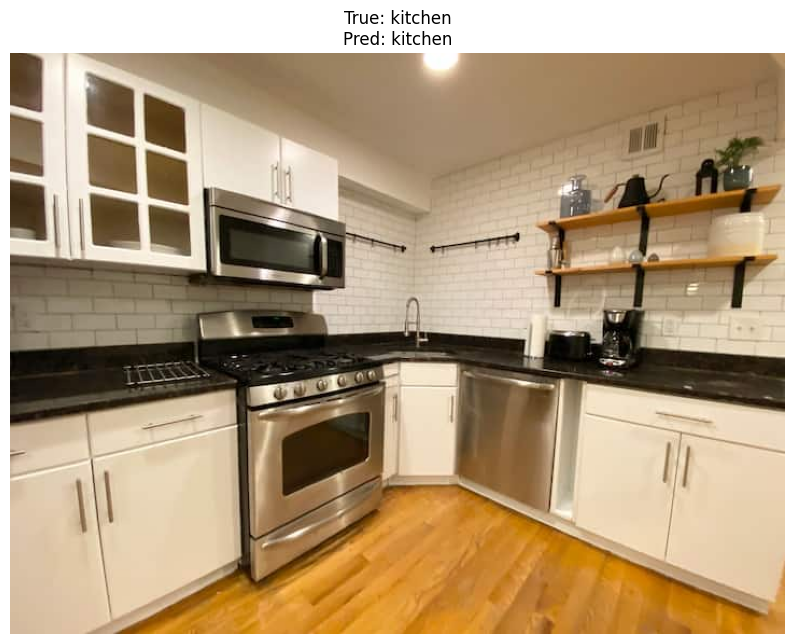

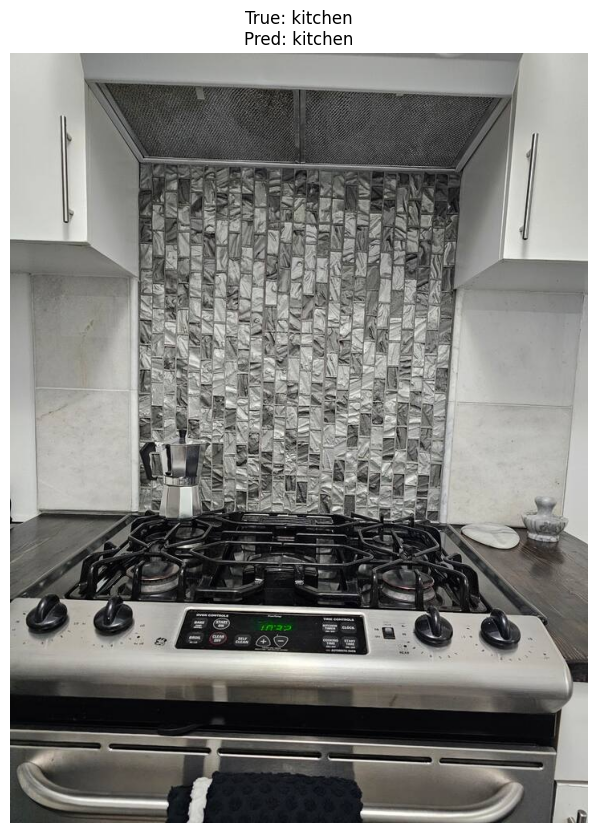

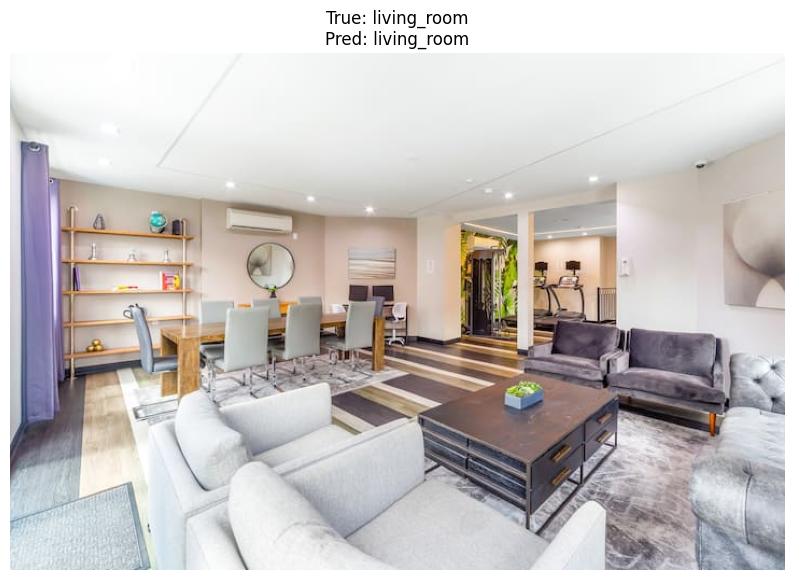

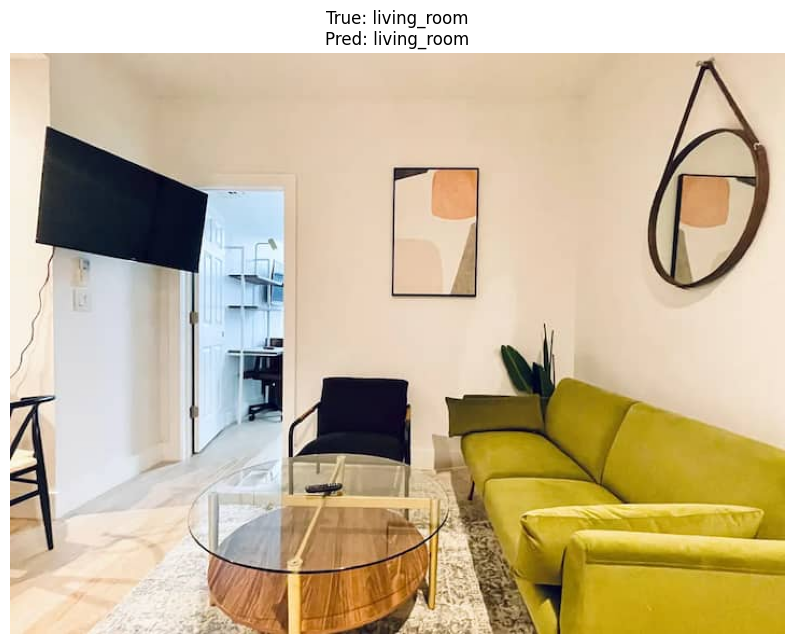

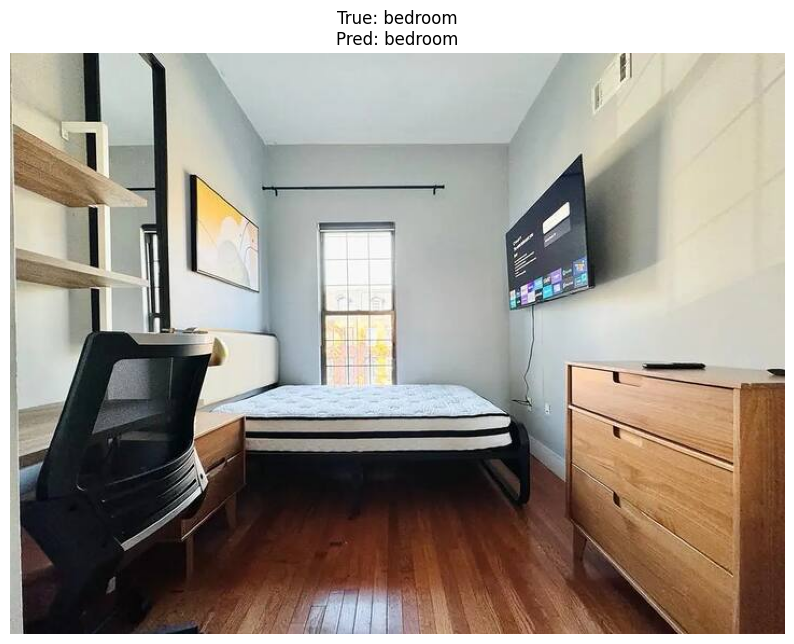

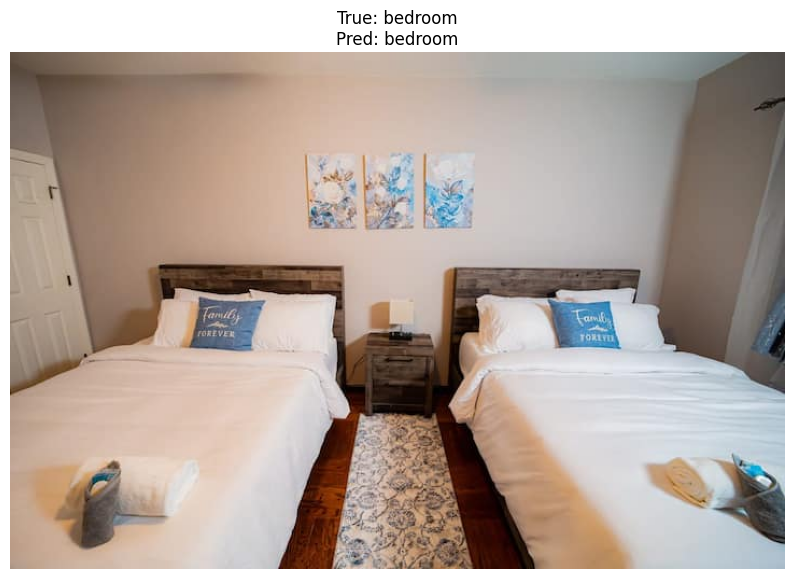

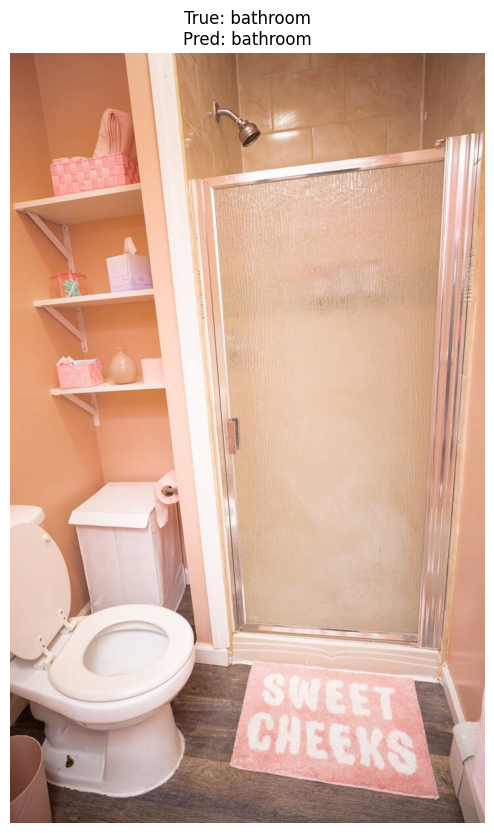

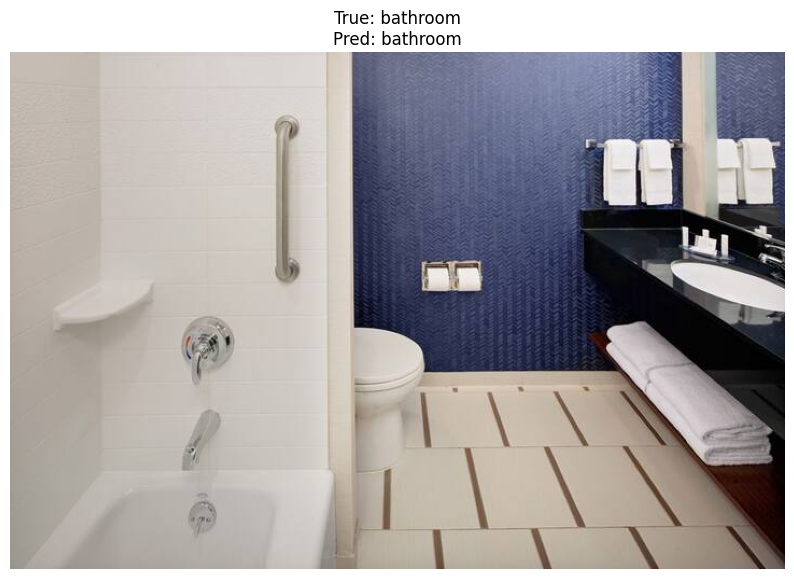

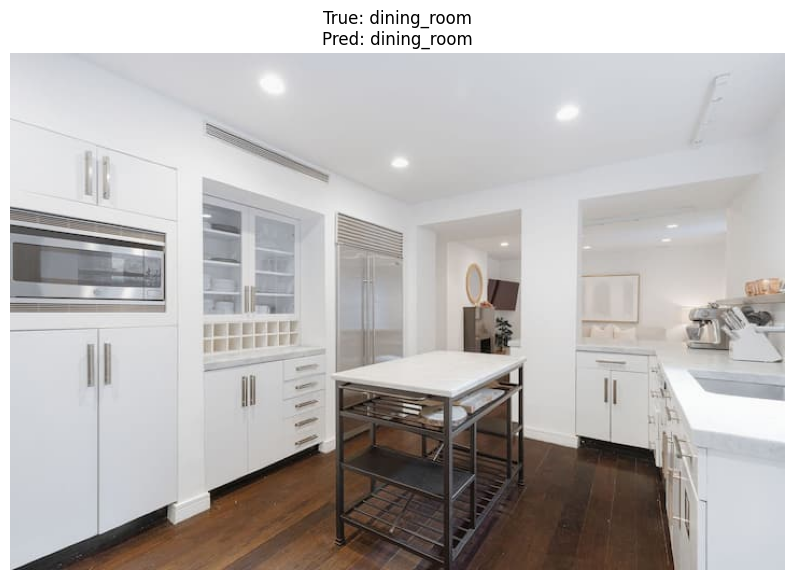

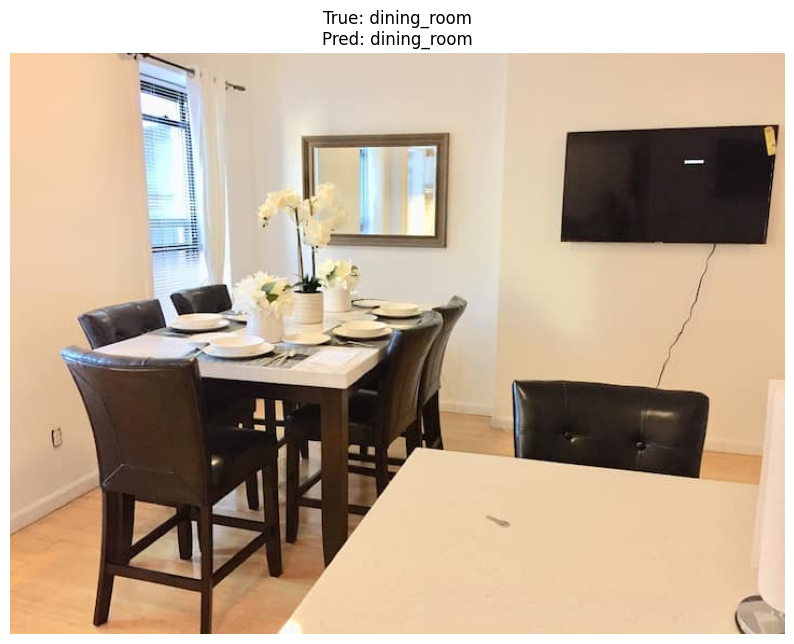

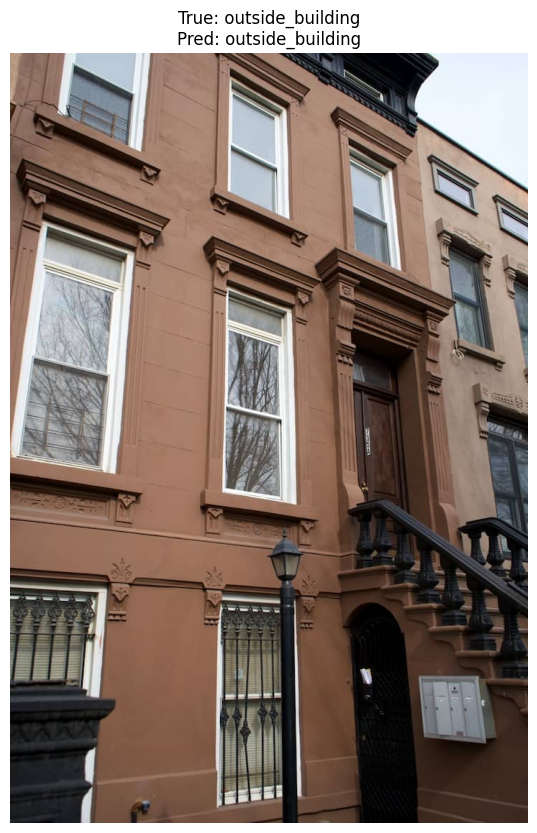

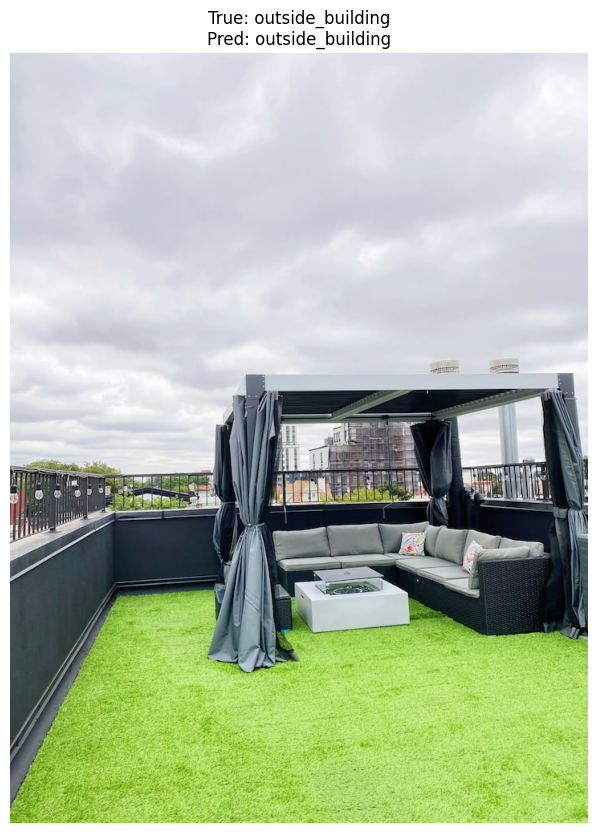

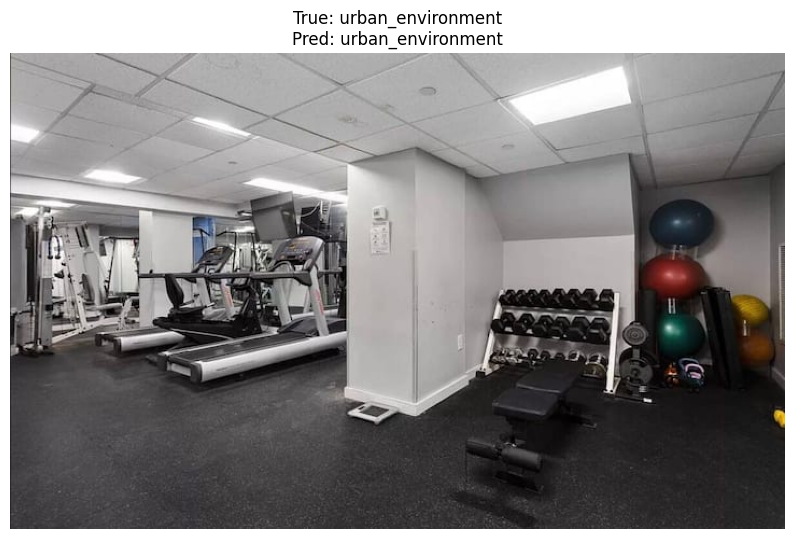

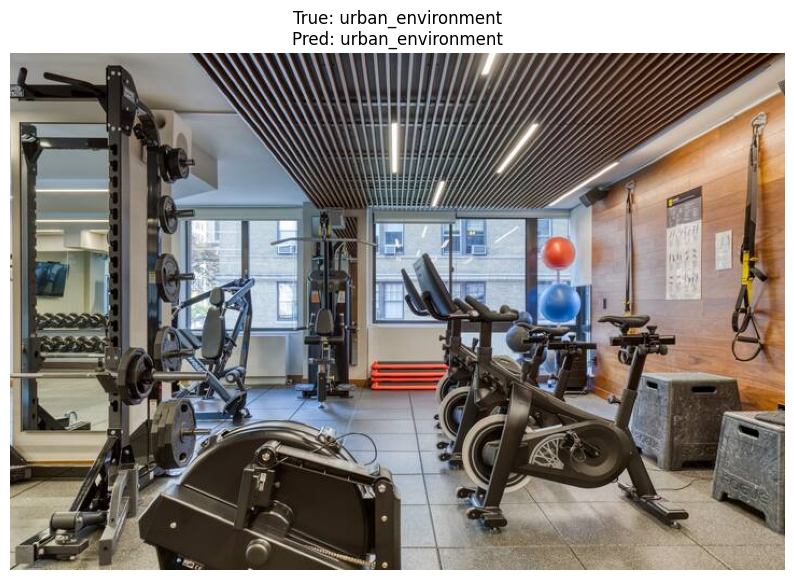

In [15]:
path = "dataset/test"
for category in settings.class_names:
    for idx, file_name in enumerate(sorted(os.listdir(f"{path}/{category}"))):
        file_path = f"{path}/{category}/{file_name}"
        image, label = ImageReader()(file_path, category)
        prediction = room_type_model.predict(image)["room_type"]
        plt.figure(figsize=(10, 10))
        plt.title(f"True: {label}\nPred: {prediction}")
        plt.imshow(image)
        plt.axis("off")
        plt.show()
        if idx == 1:
            break

# Verifying the results

In [5]:
def multilabel_conf_matrix(y_true, y_pred, labels, normalize=False):
    if normalize == True:
        CM = confusion_matrix(y_true, y_pred, normalize="true")
        title = "Normalized confusion matrix"
    else:
        CM = confusion_matrix(y_true, y_pred, normalize=None)
        title = "Confusion matrix"
    x = [str(i) for i in labels]
    fig = go.Figure()
    z_text = np.round(CM, 3).astype(str)
    fig.add_trace(
        go.Heatmap(
            z=CM,
            x=x,
            y=x,
            colorscale="blues",
            showscale=True,
            text=z_text,
            texttemplate="%{text}",
        )
    )
    fig.update_layout(
        template="simple_white",
        width=600,
        height=600,
        showlegend=False,
        font=dict(family="Times New Roman", size=16, color="Black"),
        title_text="<b>{}<br>F1 score: {}<b>".format(
            title,
            np.round(f1_score(y_true, y_pred, average="macro", zero_division=1.0), 4),
        ),
        title_x=0.5,
        title_y=0.97,
    )
    fig.add_annotation(
        dict(
            font=dict(family="Times New Roman", size=20, color="Black"),
            x=-0.25,
            y=0.5,
            showarrow=False,
            text="True",
            textangle=-90,
            xref="paper",
            yref="paper",
        )
    )
    fig.add_annotation(
        dict(
            font=dict(family="Times New Roman", size=20, color="Black"),
            x=0.5,
            y=-0.2,
            showarrow=False,
            text="Pred",
            xref="paper",
            yref="paper",
        )
    )
    fig.show("png")


def subplot_multilabel_conf_matrix(
    y_true, probabilities, labels, threshold, normalize=False, default_class=1
):
    y_pred_no_threshold = [
        RoomTypeClassification.ROOM_TYPE_DICT[int(np.argmax(prob))]
        for prob in probabilities
    ]
    y_pred_threshold = [
        (
            RoomTypeClassification.ROOM_TYPE_DICT[int(np.argmax(prob))]
            if max(prob) >= threshold
            else default_class
        )
        for prob in probabilities
    ]
    if normalize == True:
        CM_no_threshold = confusion_matrix(
            y_true, y_pred_no_threshold, normalize="true"
        )
        CM_threshold = confusion_matrix(y_true, y_pred_threshold, normalize="true")
        title = "Normalized confusion matrix"
    else:
        CM_no_threshold = confusion_matrix(y_true, y_pred_no_threshold, normalize=None)
        CM_threshold = confusion_matrix(y_true, y_pred_threshold, normalize=None)
        title = "Confusion matrix"
    x = [str(i) for i in labels]
    z_text_no_threshold = np.around(CM_no_threshold, 3).astype(str)
    z_text_threshold = np.around(CM_threshold, 3).astype(str)
    from plotly.subplots import make_subplots

    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=(
            f"<b>No Threshold<br>F1 Score: {f1_score(y_true, y_pred_no_threshold, average='macro'):.4f}<b>",
            f"<b>Threshold {threshold:.2f}<br>F1 Score: {f1_score(y_true, y_pred_threshold, average='macro'):.4f}<b>",
        ),
    )
    fig.add_trace(
        go.Heatmap(
            z=CM_no_threshold,
            x=x,
            y=x,
            colorscale="blues",
            showscale=True,
            text=z_text_no_threshold,
            texttemplate="%{text}",
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Heatmap(
            z=CM_threshold,
            x=x,
            y=x,
            colorscale="blues",
            showscale=True,
            text=z_text_threshold,
            texttemplate="%{text}",
        ),
        row=1,
        col=2,
    )
    fig.update_layout(
        template="simple_white",
        width=1600,
        height=800,
        showlegend=False,
        font=dict(family="Times New Roman", size=16, color="Black"),
        title_text=f"<b>{title}<b>",
        title_x=0.5,
        title_y=0.97,
    )
    fig.add_annotation(
        dict(
            font=dict(family="Times New Roman", size=20, color="Black"),
            x=-0.1,
            y=0.5,
            showarrow=False,
            text="True",
            textangle=-90,
            xref="paper",
            yref="paper",
        )
    )
    fig.add_annotation(
        dict(
            font=dict(family="Times New Roman", size=20, color="Black"),
            x=0.19,
            y=-0.1,
            showarrow=False,
            text="Pred",
            xref="paper",
            yref="paper",
        )
    )
    fig.add_annotation(
        dict(
            font=dict(family="Times New Roman", size=20, color="Black"),
            x=0.48,
            y=0.5,
            showarrow=False,
            text="True",
            textangle=-90,
            xref="paper",
            yref="paper",
        )
    )
    fig.add_annotation(
        dict(
            font=dict(family="Times New Roman", size=20, color="Black"),
            x=0.81,
            y=-0.1,
            showarrow=False,
            text="Pred",
            xref="paper",
            yref="paper",
        )
    )
    fig.show("png")


def plot_metrics_per_dataset(
    train_labels,
    train_predictions,
    valid_labels,
    valid_predictions,
    test_labels,
    test_predictions,
    labels,
):
    train_accuracy = accuracy_score(train_labels, train_predictions)
    valid_accuracy = accuracy_score(valid_labels, valid_predictions)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    train_precision = precision_score(train_labels, train_predictions, average="macro")
    valid_precision = precision_score(valid_labels, valid_predictions, average="macro")
    test_precision = precision_score(test_labels, test_predictions, average="macro")
    train_recall = recall_score(train_labels, train_predictions, average="macro")
    valid_recall = recall_score(valid_labels, valid_predictions, average="macro")
    test_recall = recall_score(test_labels, test_predictions, average="macro")
    train_f1 = f1_score(train_labels, train_predictions, average="macro")
    valid_f1 = f1_score(valid_labels, valid_predictions, average="macro")
    test_f1 = f1_score(test_labels, test_predictions, average="macro")
    fig = go.Figure()
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    colors = px.colors.qualitative.Bold
    fig.add_trace(
        go.Bar(
            x=metrics,
            y=[train_accuracy, train_precision, train_recall, train_f1],
            text=[
                round(i, 3)
                for i in [train_accuracy, train_precision, train_recall, train_f1]
            ],
            textposition="auto",
            name="Train",
            marker_color=colors[0],
        )
    )
    fig.add_trace(
        go.Bar(
            x=metrics,
            y=[valid_accuracy, valid_precision, valid_recall, valid_f1],
            text=[
                round(i, 3)
                for i in [valid_accuracy, valid_precision, valid_recall, valid_f1]
            ],
            textposition="auto",
            name="Valid",
            marker_color=colors[1],
        )
    )
    fig.add_trace(
        go.Bar(
            x=metrics,
            y=[test_accuracy, test_precision, test_recall, test_f1],
            text=[
                round(i, 3)
                for i in [test_accuracy, test_precision, test_recall, test_f1]
            ],
            textposition="auto",
            name="Test",
            marker_color=colors[2],
        )
    )
    fig.update_layout(
        barmode="group",
        template="simple_white",
        width=1200,
        height=600,
        yaxis_title="Average metric value",
        xaxis_title="Metric",
        title=f"<b>Metrics for different datasets<b>",
        title_x=0.5,
        font=dict(family="Times New Roman", size=16, color="Black"),
    )
    fig.show("png")


def plot_probabilities_per_class(dataset_name, y_true, y_pred, probabilities):
    for class_name in settings.class_names:
        true_class_indices = np.where(y_true == class_name)[0]
        wide_x_list = [
            str(class_name)
            for _ in range(len(true_class_indices))
            for class_name in settings.class_names
        ]
        wide_prob_list = probabilities[true_class_indices].flatten()
        df_temp = pd.DataFrame({"Y": wide_x_list, "Pred_Proba": wide_prob_list})
        fig = px.strip(
            df_temp,
            y="Y",
            x="Pred_Proba",
            color="Y",
            stripmode="overlay",
            orientation="h",
            title="Beeswarm Plot",
            labels={"Y": "True Class", "Pred_Proba": "Predicted Probability"},
        )
        fig.update_layout(
            template="simple_white",
            width=1000,
            height=600,
            showlegend=False,
            title=f"{dataset_name.title()}: Probability distribution for true class: {class_name}",
            title_x=0.5,
            yaxis_title="Class",
            xaxis_title="Probability",
            font=dict(family="Times New Roman", size=16, color="Black"),
        )
        fig.update_xaxes(range=[-0.01, 1.01])
        fig.update_layout(boxgap=0)
        fig.update_traces(jitter=0.9, marker={"size": 5})
        fig.show("png")


def plot_f1_against_threshold(
    train_labels,
    train_probabilities,
    valid_labels,
    valid_probabilities,
    test_labels,
    test_probabilities,
    default_class=1,
):
    thresholds = np.linspace(0, 1, 101)
    train_f1_scores, valid_f1_scores, test_f1_scores = [], [], []
    for threshold in thresholds:
        y_pred = [
            (
                RoomTypeClassification.ROOM_TYPE_DICT[int(np.argmax(prob))]
                if max(prob) >= threshold
                else default_class
            )
            for prob in train_probabilities
        ]
        train_f1_scores.append(f1_score(train_labels, y_pred, average="macro"))
        y_pred = [
            (
                RoomTypeClassification.ROOM_TYPE_DICT[int(np.argmax(prob))]
                if max(prob) >= threshold
                else default_class
            )
            for prob in valid_probabilities
        ]
        valid_f1_scores.append(f1_score(valid_labels, y_pred, average="macro"))
        y_pred = [
            (
                RoomTypeClassification.ROOM_TYPE_DICT[int(np.argmax(prob))]
                if max(prob) >= threshold
                else default_class
            )
            for prob in test_probabilities
        ]
        test_f1_scores.append(f1_score(test_labels, y_pred, average="macro"))
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=thresholds,
            y=train_f1_scores,
            mode="lines",
            name="Train F1 Score",
            line=dict(color="blue", width=2),
        )
    )
    fig.add_trace(
        go.Scatter(
            x=thresholds,
            y=valid_f1_scores,
            mode="lines",
            name="Valid F1 Score",
            line=dict(color="green", width=2),
        )
    )
    fig.add_trace(
        go.Scatter(
            x=thresholds,
            y=test_f1_scores,
            mode="lines",
            name="Test F1 Score",
            line=dict(color="orange", width=2),
        )
    )
    mean_f1_train_valid = [
        (train_f1_scores[i] + valid_f1_scores[i]) / 2 for i in range(len(thresholds))
    ]
    max_f1 = max(mean_f1_train_valid)
    max_f1_index = mean_f1_train_valid.index(max_f1)
    max_f1_score_threshold = thresholds[max_f1_index]
    fig.add_trace(
        go.Scatter(
            x=[max_f1_score_threshold],
            y=[max_f1],
            mode="markers",
            marker=dict(color="red", size=10),
            name=f"Best threshold: {round(max_f1_score_threshold, 2)}",
        )
    )
    fig.update_layout(
        template="simple_white",
        width=1000,
        height=600,
        showlegend=True,
        title=f"F1 Score against threshold<br>Max average F1: {round(max_f1, 4)}",
        title_x=0.5,
        yaxis_title="F1 Score",
        xaxis_title="Threshold",
        font=dict(family="Times New Roman", size=16, color="Black"),
    )
    fig.update_xaxes(range=[-0.01, 1.01])
    fig.update_yaxes(range=[-0.01, 1.01])
    fig.show("png")
    return max_f1_score_threshold


def plot_scores_comparision_threshold(
    train_labels,
    train_probabilities,
    valid_labels,
    valid_probabilities,
    test_labels,
    test_probabilities,
    labels,
    threshold,
    default_class=1,
):
    def calculate_f1_score(y_true, probabilities, threshold, labels, default_class):
        y_pred = [
            (
                RoomTypeClassification.ROOM_TYPE_DICT[int(np.argmax(prob))]
                if max(prob) >= threshold
                else default_class
            )
            for prob in probabilities
        ]
        return f1_score(y_true, y_pred, average="macro")

    train_f1_no_threshold = calculate_f1_score(
        train_labels, train_probabilities, 0, labels, default_class
    )
    valid_f1_no_threshold = calculate_f1_score(
        valid_labels, valid_probabilities, 0, labels, default_class
    )
    test_f1_no_threshold = calculate_f1_score(
        test_labels, test_probabilities, 0, labels, default_class
    )
    train_f1_threshold = calculate_f1_score(
        train_labels, train_probabilities, threshold, labels, default_class
    )
    valid_f1_threshold = calculate_f1_score(
        valid_labels, valid_probabilities, threshold, labels, default_class
    )
    test_f1_threshold = calculate_f1_score(
        test_labels, test_probabilities, threshold, labels, default_class
    )
    colors = px.colors.qualitative.Bold
    fig = go.Figure()
    fig.add_trace(
        go.Bar(
            x=["Train", "Valid", "Test"],
            y=[train_f1_no_threshold, valid_f1_no_threshold, test_f1_no_threshold],
            text=[
                round(i, 3)
                for i in [
                    train_f1_no_threshold,
                    valid_f1_no_threshold,
                    test_f1_no_threshold,
                ]
            ],
            textposition="auto",
            marker=dict(color=colors[2]),
            name="No threshold",
        )
    )
    fig.add_trace(
        go.Bar(
            x=["Train", "Valid", "Test"],
            y=[train_f1_threshold, valid_f1_threshold, test_f1_threshold],
            text=[
                round(i, 3)
                for i in [train_f1_threshold, valid_f1_threshold, test_f1_threshold]
            ],
            textposition="auto",
            marker=dict(color=colors[3]),
            name=f"Threshold: {threshold}",
        )
    )
    fig.update_layout(
        template="simple_white",
        width=1000,
        height=600,
        showlegend=True,
        title=f"F1 score comparision",
        title_x=0.5,
        yaxis_title="F1 score",
        font=dict(family="Times New Roman", size=16, color="Black"),
    )
    fig.show("png")

## pt vs onnx

In [6]:
test_class = Test(onnx_model_path)
criterion = torch.nn.CrossEntropyLoss()
model = get_model(num_classes=settings.num_classes).to(settings.device)
model_save_path = f"{settings.LOGGED_MODELS_PATH}/best.pt"
state_dict = torch.load(model_save_path, weights_only=False)
model.eval()
model.load_state_dict(state_dict)
(
    test_loss,
    test_accuracy,
    test_precision,
    test_recall,
    test_f1,
    test_confusion_matrix,
) = test_class.test_model(
    model, dataloader_utils.dataloaders["test"], "test", criterion
)
print(
    f"Test_loss: {round(test_loss, 4)} | Test_accuracy: {round(test_accuracy, 4)} | Test_precision {round(test_precision, 4)} | Test_recall: {round(test_recall, 4)} | Test_f1: {round(test_f1, 4)}\n"
)

Testing test dataset: 100%|██████████| 18975/18975 [02:32<00:00, 124.69it/s]


Test_loss: 0.1023 | Test_accuracy: 0.9778 | Test_precision 0.9693 | Test_recall: 0.9703 | Test_f1: 0.9698



Inference train dataset: 100%|██████████| 88.5k/88.5k [20:20<00:00, 72.5images/s]


train_accuracy: 0.999 | train_precision: 0.9984 | train_recall: 0.9984 | train_f1: 0.9984


Inference val dataset: 100%|██████████| 19.0k/19.0k [04:06<00:00, 76.9images/s]


val_accuracy: 0.9795 | val_precision: 0.9715 | val_recall: 0.9728 | val_f1: 0.9721


Inference test dataset: 100%|██████████| 19.0k/19.0k [04:00<00:00, 79.0images/s]


test_accuracy: 0.9778 | test_precision: 0.9694 | test_recall: 0.9704 | test_f1: 0.9699


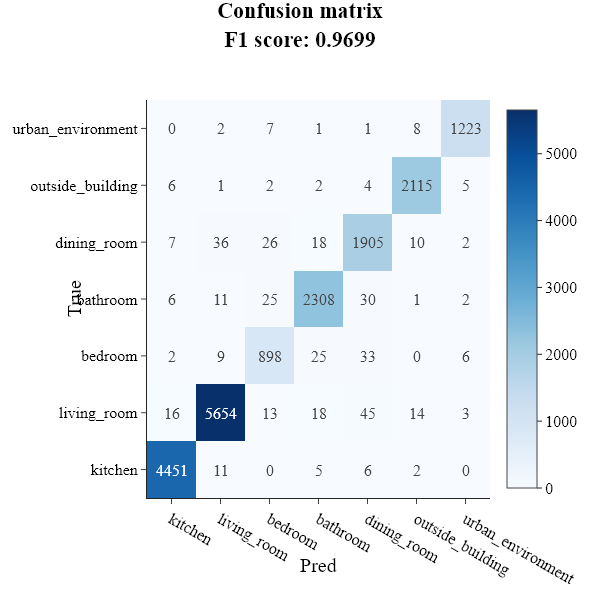

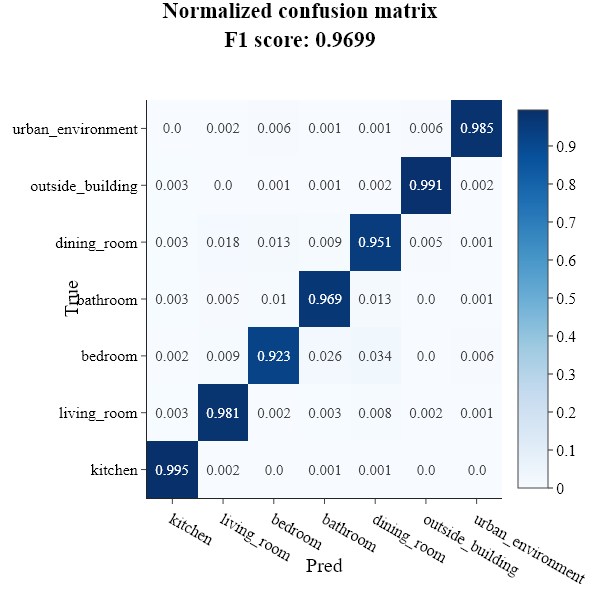

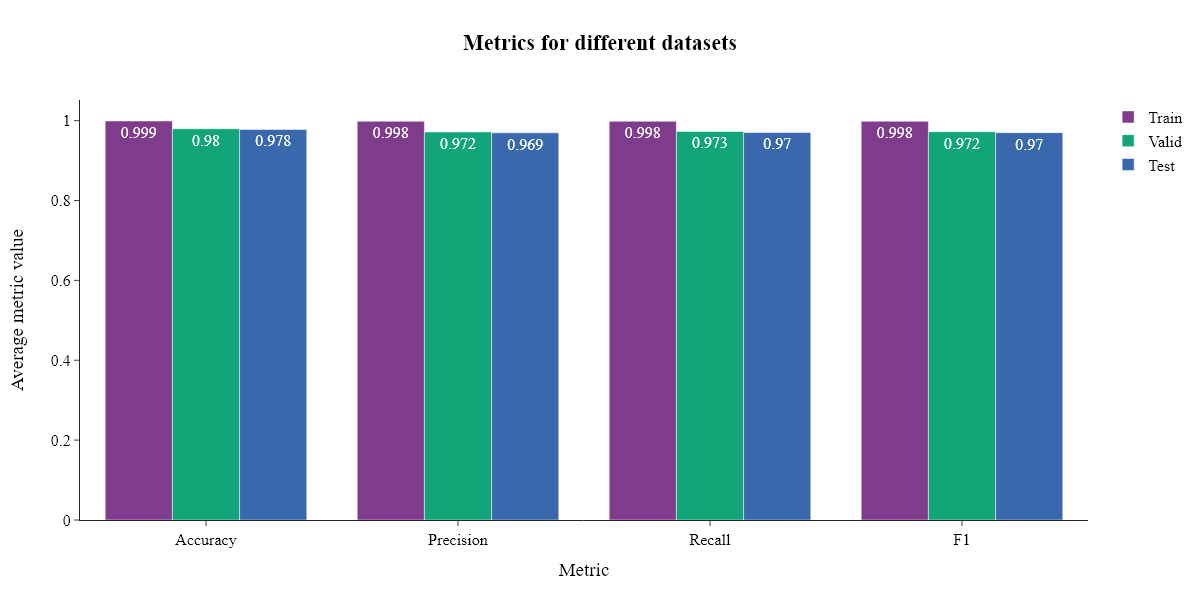

In [7]:
def test_onnx_model(path):
    dataset_name = path.split("/")[-1]
    labels = np.array([], dtype=np.int32)
    predictions = np.array([], dtype=np.int32)
    probabilities = np.array([], dtype=np.float32).reshape(0, len(settings.class_names))
    with tqdm(
        total=sum(
            [len(os.listdir(f"{path}/{category}")) for category in settings.class_names]
        ),
        unit="images",
        unit_scale=True,
        desc=f"Inference {dataset_name} dataset",
    ) as pbar:
        for category in settings.class_names:
            for idx, file_name in enumerate(sorted(os.listdir(f"{path}/{category}"))):
                file_path = f"{path}/{category}/{file_name}"
                image, label = ImageReader()(file_path, category)
                prediction = room_type_model.predict(image)
                labels = np.append(labels, label)
                predictions = np.append(predictions, prediction["room_type"])
                probabilities = np.vstack([probabilities, prediction["probabilities"]])
                pbar.update(1)
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average="macro", zero_division=1.0)
    recall = recall_score(labels, predictions, average="macro", zero_division=1.0)
    f1 = f1_score(labels, predictions, average="macro", zero_division=1.0)
    print(
        f"{dataset_name}_accuracy: {round(accuracy, 4)} | {dataset_name}_precision: {round(precision, 4)} | {dataset_name}_recall: {round(recall, 4)} | {dataset_name}_f1: {round(f1, 4)}"
    )
    return labels, predictions, probabilities


train_labels, train_predictions, train_probabilities = test_onnx_model("dataset/train")
val_labels, val_predictions, val_probabilities = test_onnx_model("dataset/val")
test_labels, test_predictions, test_probabilities = test_onnx_model("dataset/test")
multilabel_conf_matrix(
    test_labels, test_predictions, settings.class_names, normalize=False
)
multilabel_conf_matrix(
    test_labels, test_predictions, settings.class_names, normalize=True
)
plot_metrics_per_dataset(
    train_labels,
    train_predictions,
    val_labels,
    val_predictions,
    test_labels,
    test_predictions,
    labels=settings.class_names,
)

## Probabilities

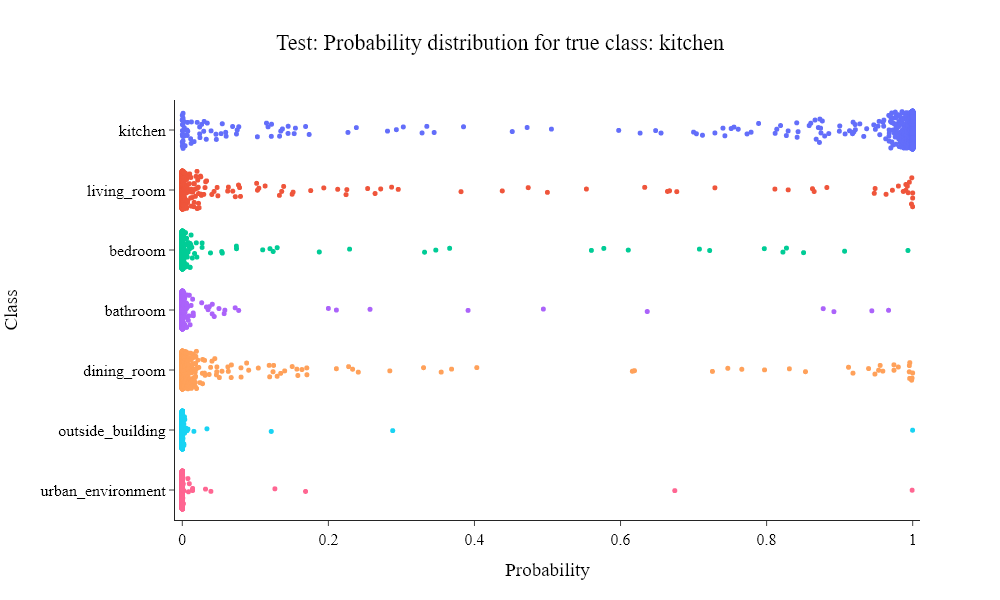

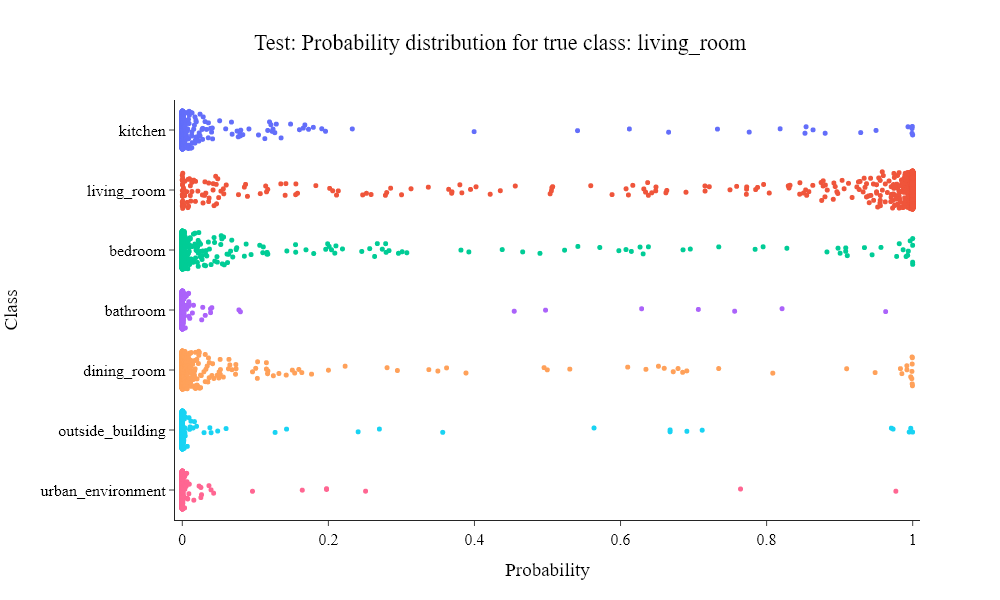

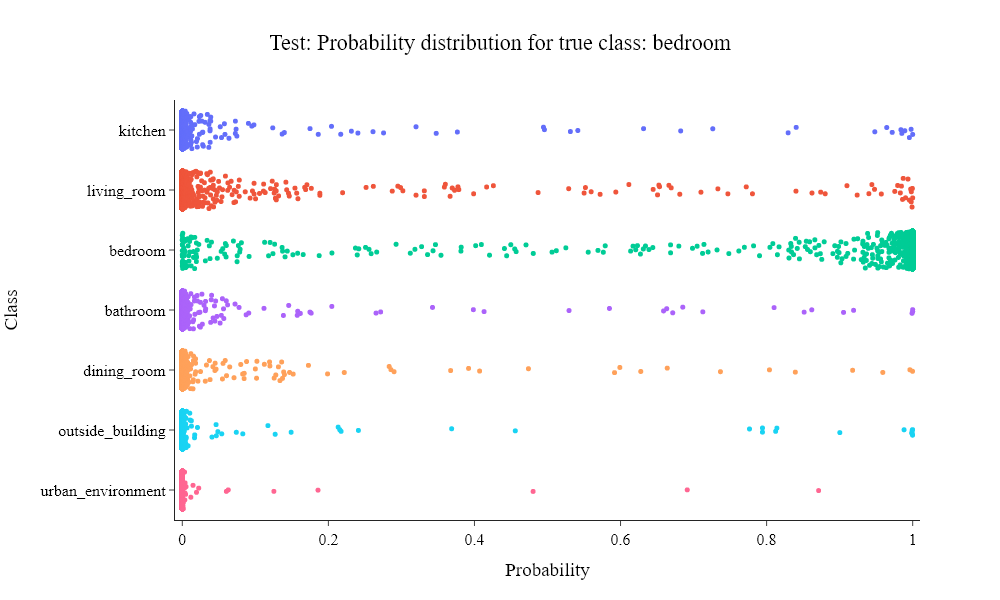

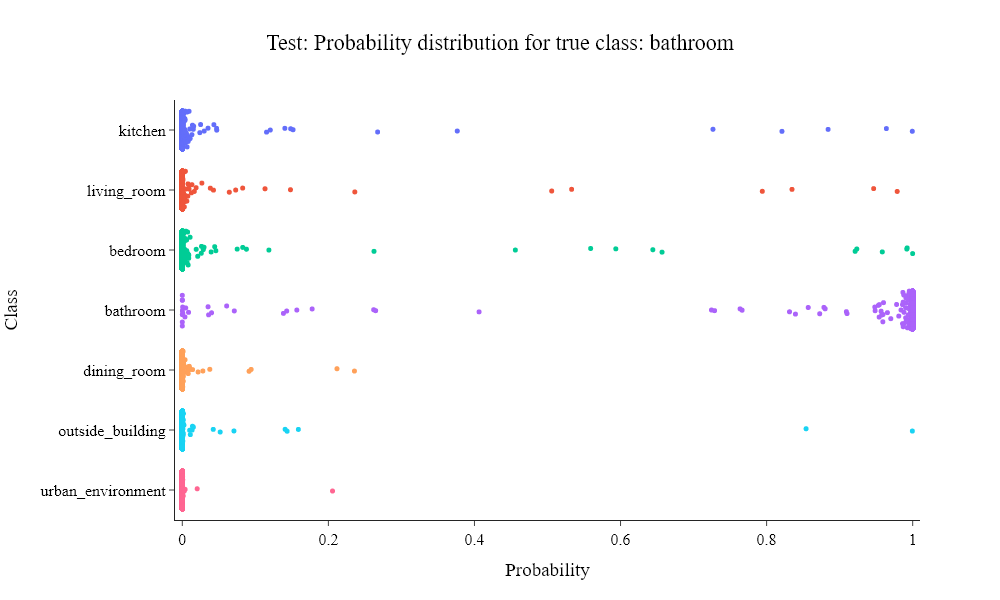

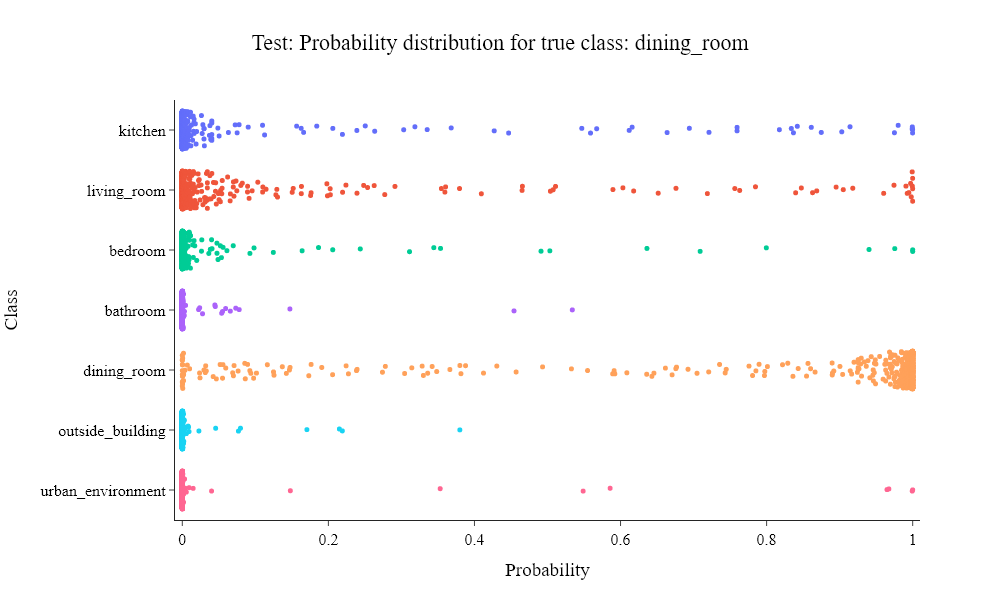

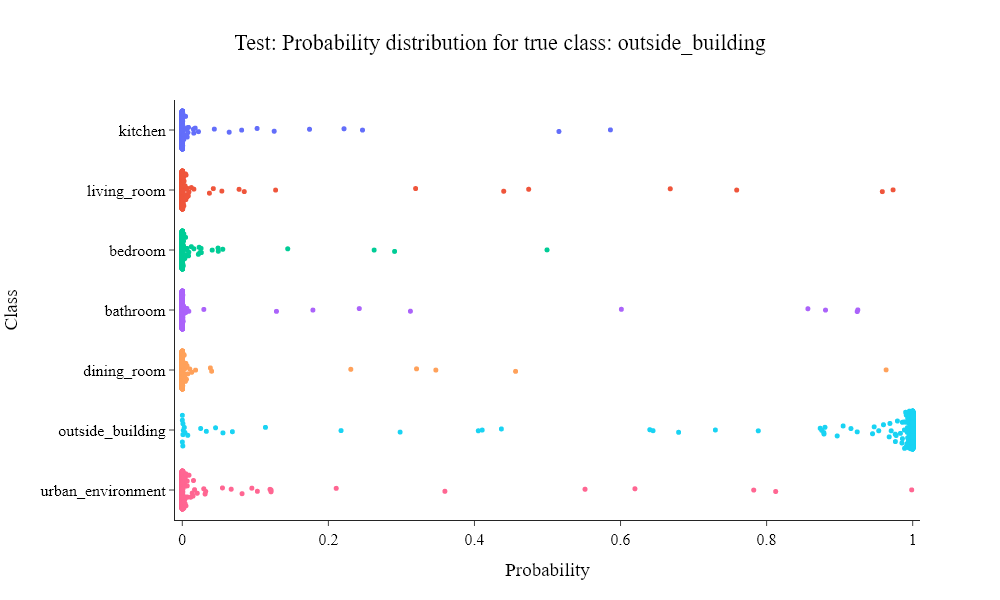

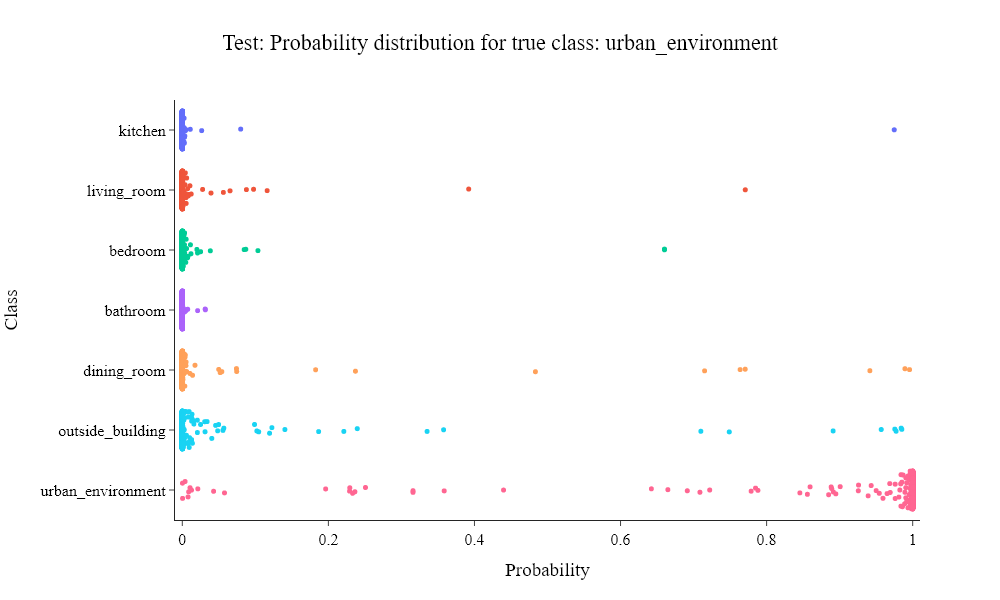

In [8]:
dataset_name = "dataset/test".split("/")[-1]
plot_probabilities_per_class(
    dataset_name, test_labels, test_predictions, test_probabilities
)

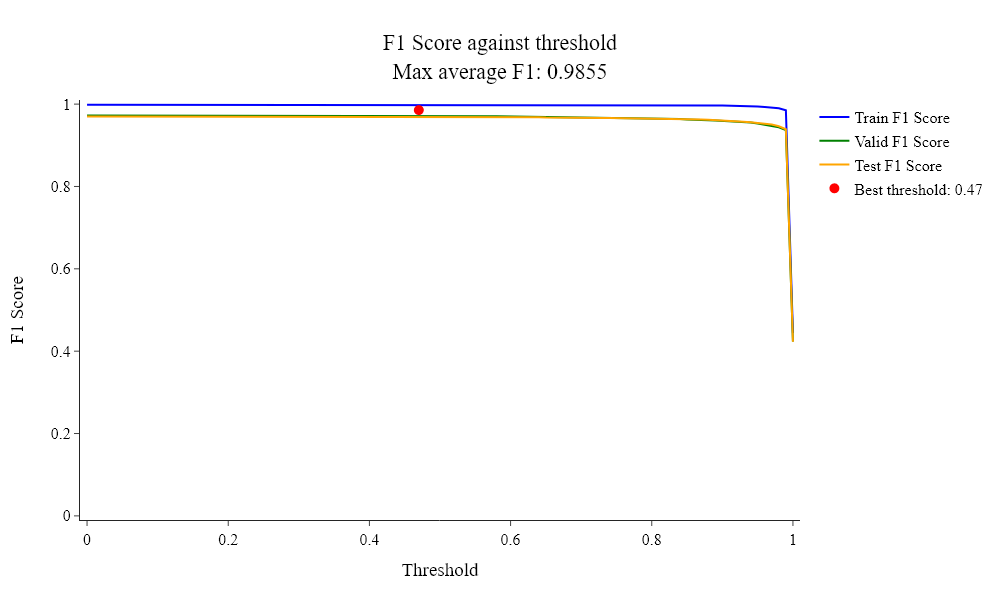

In [9]:
max_f1_score_threshold = plot_f1_against_threshold(
    train_labels,
    train_probabilities,
    val_labels,
    val_probabilities,
    test_labels,
    test_probabilities,
    default_class="kitchen",
)

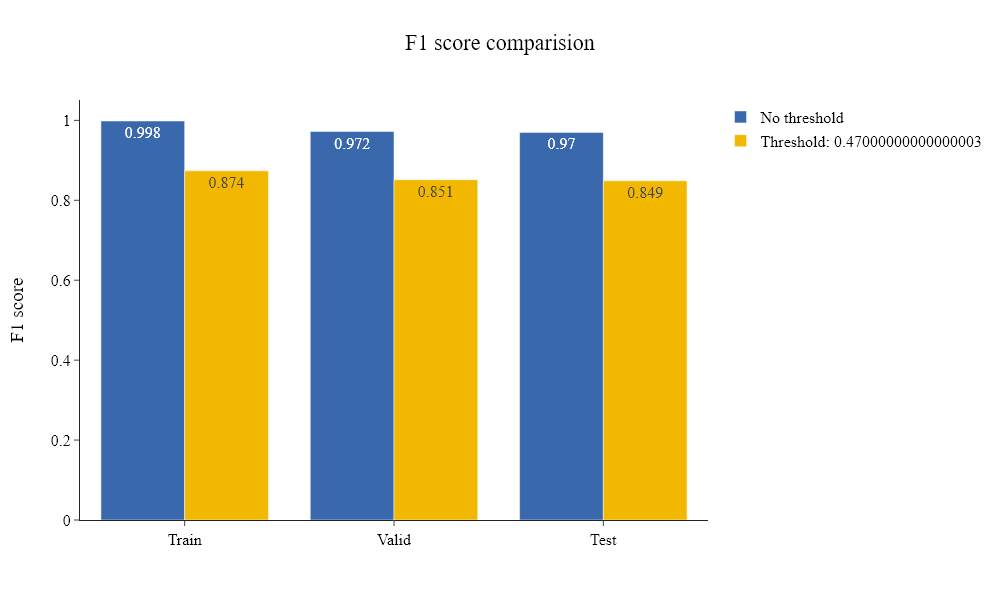

In [10]:
plot_scores_comparision_threshold(
    train_labels,
    train_probabilities,
    val_labels,
    val_probabilities,
    test_labels,
    test_probabilities,
    labels=settings.class_names,
    threshold=max_f1_score_threshold,
    default_class=1,
)

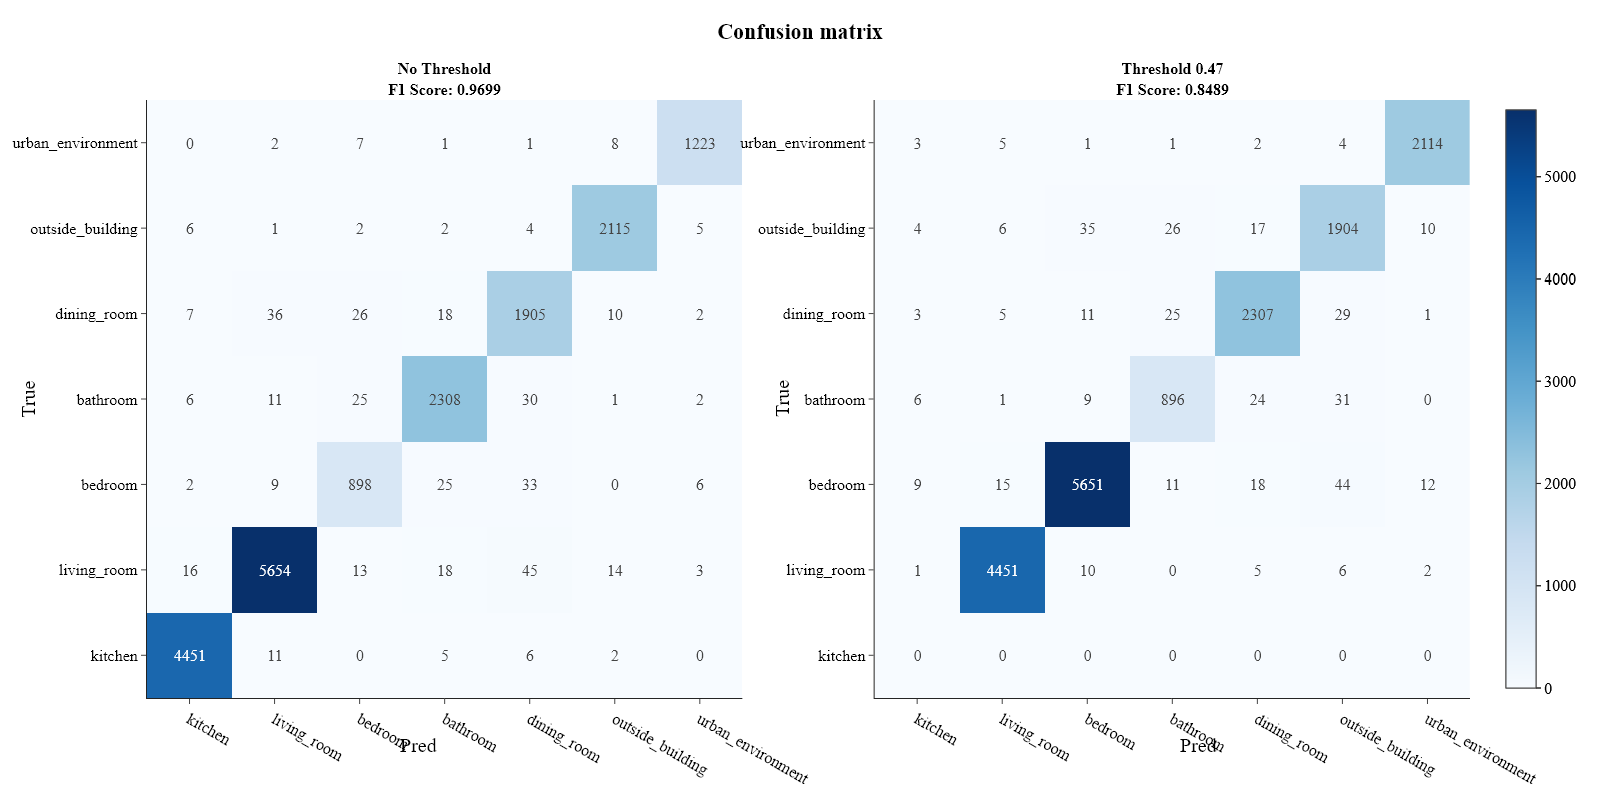

In [11]:
subplot_multilabel_conf_matrix(
    test_labels,
    test_probabilities,
    settings.class_names,
    threshold=max_f1_score_threshold,
    normalize=False,
)

## Wrong predictions

In [ ]:
path = "dataset/test"
for category in settings.class_names:
    for idx, file_name in enumerate(sorted(os.listdir(f"{path}/{category}"))):
        file_path = f"{path}/{category}/{file_name}"
        image, label = ImageReader()(file_path, category)
        prediction = room_type_model.predict(image)
        pred_room_type = prediction["room_type"]
        prob = prediction["probability"]
        if pred_room_type != label and prob >= 0.99:
            print(file_name)
            plt.figure(figsize=(10, 10))
            plt.title(f"True: {label}\nPred: {pred_room_type}; Prob: {round(prob, 4)}")
            plt.imshow(image)
            plt.axis("off")
            plt.show()
            break